In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import freqz;

fs = 48000

0.9999999999999999 0.9463347633757274 0.05366523662427258


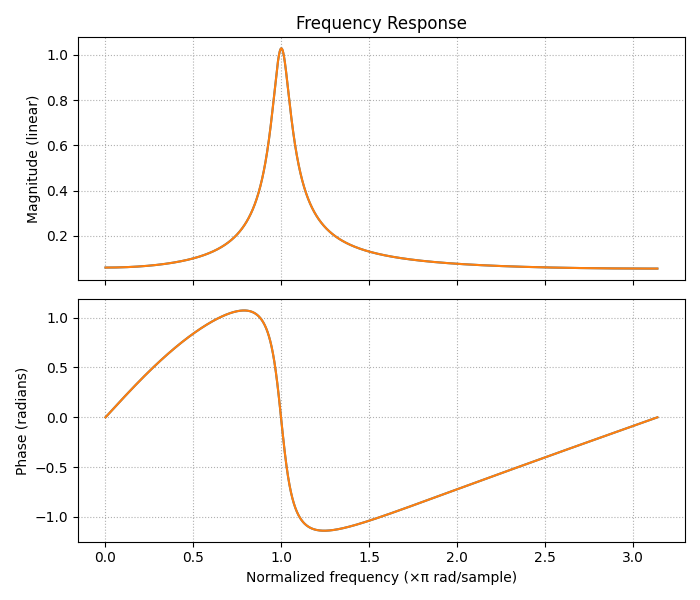

In [ ]:
def desgnfilt(cf, rht):
    return np.exp(1j * cf) * np.pow(0.5, 1 / (2 * np.pi * rht / cf))

a = desgnfilt(1, 2)
print(np.angle(a), np.abs(a), 1-abs(a))

def fresp(fn, a):
    z = np.exp(-1j * fn)
    return (1-np.abs(a)) * ( 1 / (1 - a * z) + 1 / (1 - np.conj(a) * z))
    #b = (a + np.conj(a))
    #return (1-np.abs(a)) * (2 - b * z) / (1 - b * z + a * np.conj(a) * z * z)

n = 1024 * 16
fnorm = np.arange(n) / n * np.pi

freq = fresp(fnorm, a)
amp = np.abs(freq)
ang = np.unwrap(np.angle(freq))

def filtere(x, a):
    y = np.zeros(len(x))
    s = 0
    f = 1 - np.abs(a)
    for i in range(len(x)):
        s = s * a + f * x[i]
        y[i] = 2 * np.real(s)
    return y

impulse = np.zeros(2*n)
impulse[0] = 1
impulse = filtere(impulse, a)
freqsim = np.fft.fft(impulse)[0:n]
angsim = np.unwrap(np.angle(freqsim))
ampsim = np.abs(freqsim)
fnorm2 = np.linspace(0, np.pi, len(freqsim))

fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

# Magnitude (linear)
axs[0].plot(fnorm, amp, color='C0', lw=1.5)
axs[0].plot(fnorm2, ampsim, color='C1', lw=1.5)
axs[0].set_ylabel('Magnitude (linear)')
axs[0].grid(True, which='both', ls=':')
axs[0].set_title('Frequency Response')

# Phase (radians)
axs[1].plot(fnorm, ang, color='C0', lw=1.5)
axs[1].plot(fnorm2, angsim, color='C1', lw=1.5)
axs[1].set_xlabel('Normalized frequency (×π rad/sample)')
axs[1].set_ylabel('Phase (radians)')
axs[1].grid(True, which='both', ls=':')

plt.tight_layout()
plt.show()



32


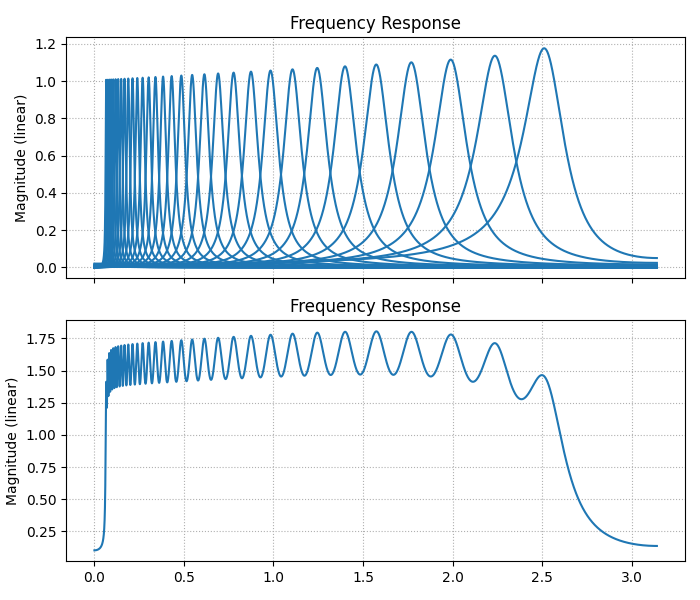

In [7]:
n = 1024 * 16
fnorm = np.arange(n) / n * np.pi

bank = []
f = 500
rht = 2
while True:
    bank.append(fresp(fnorm, desgnfilt(2*np.pi*f/fs, rht)))
    f *= 1 + (0.25  / rht)
    if f > 0.9*fs/2:
        break

fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

sumfilt = np.zeros(n)
for filt in bank:
    axs[0].plot(fnorm, np.abs(filt)**2, color='C0', lw=1.5)
    sumfilt += np.abs(filt)**2

print(len(bank))

axs[0].set_ylabel('Magnitude (linear)')
axs[0].grid(True, which='both', ls=':')
axs[0].set_title('Frequency Response')

axs[1].plot(fnorm, sumfilt, color='C0', lw=1.5)
axs[1].set_ylabel('Magnitude (linear)')
axs[1].grid(True, which='both', ls=':')
axs[1].set_title('Frequency Response')

plt.tight_layout()
plt.show()

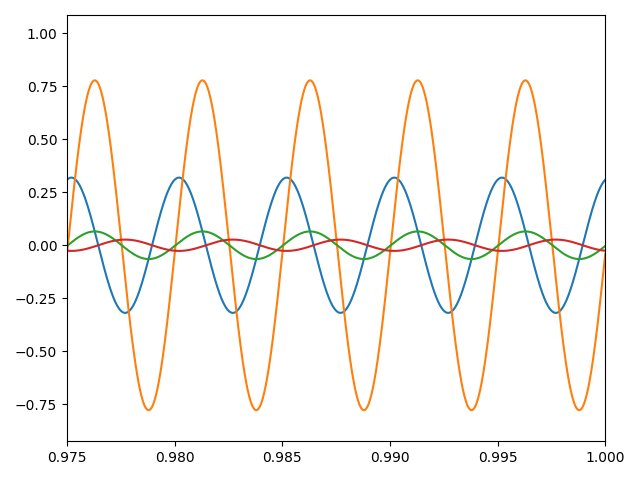

In [90]:
%matplotlib widget

def filterir(x, a):
    y = np.full(len(x), 0 + 0j)
    s = 0
    f = 1 - np.abs(a)
    for i in range(len(x)):
        s = s * a + f * x[i]
        y[i] =s
    return y

def filterii(x, a):
    y = np.full(len(x), 0 + 0j)
    s = 0
    f = 1 - np.abs(a)
    for i in range(len(x)):
        s = s * a - f * x[i] * 1j
        y[i] =s
    return y

t = np.linspace(0, 1, fs)
a = desgnfilt(2*np.pi*500/fs, 2)
ff = 200
x = np.sin(2 * np.pi * t * ff)
y = filterir(x, a)
y2 = filterii(x, a)
y /= np.max(np.abs(y))
y2 /= np.max(np.abs(y))

plt.figure()
# plt.plot(t, x, color='C0')
plt.plot(t, np.real(y), color='C0')
plt.plot(t, np.imag(y), color='C1')
plt.plot(t, np.real(y2), color='C2')
plt.plot(t, np.imag(y2), color='C3')
plt.xlim([1 - 5 / ff, 1])

plt.tight_layout()

plt.show()

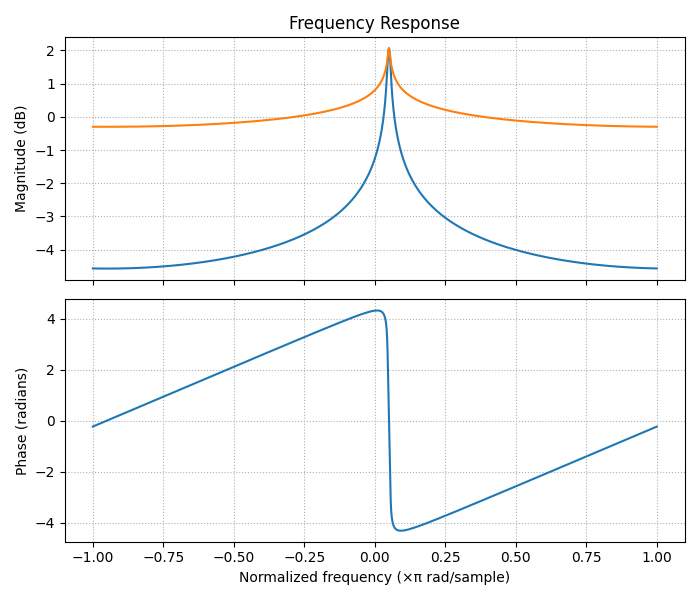

In [111]:


cf = 1200
w = 0.075
a = desgnfilt(2*np.pi*cf/fs, 2)
aa = np.convolve([1, -a*np.exp(2j*np.pi*cf/fs*w)], [1, -a*np.exp(-2j*np.pi*cf/fs*w)])
aa = np.convolve(aa, [1, -a])

e = 14
fresp = [*freqz([1], aa, 2**e, whole=True)]
fresp2 = [*freqz([1], [1, -a], 2**e, whole=True)]

for f in [fresp, fresp2]:
    f[0] = f[0] - np.pi
    f[1] = np.roll(f[1], -2**(e-1))

fig, axs = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

r = np.max(np.abs(fresp2[1])) / np.max(np.abs(fresp[1]))

# Magnitude (linear)
axs[0].plot(fresp[0] / np.pi, np.log10(r * np.abs(fresp[1])), color='C0', lw=1.5)
axs[0].plot(fresp[0] / np.pi,  np.log10(np.abs(fresp2[1])), color='C1', lw=1.5)
axs[0].set_ylabel('Magnitude (dB)')
axs[0].grid(True, which='both', ls=':')
axs[0].set_title('Frequency Response')

# Phase (radians)
axs[1].plot(fresp[0] / np.pi, np.unwrap(np.angle(fresp[1])), color='C0', lw=1.5)
axs[1].set_xlabel('Normalized frequency (×π rad/sample)')
axs[1].set_ylabel('Phase (radians)')
axs[1].grid(True, which='both', ls=':')

plt.tight_layout()
plt.show()

